In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from julia.api import Julia
jl = Julia(compiled_modules=False)
from julia import Main


# load TMDFF code + LHAPDF wrapper
Main.include("TMDFF_code")
Main.include("../Collinear_PDF/lhapdf.jl")
Main.set_lhapdf(1, "NPC23_PIp_nlo", 0)


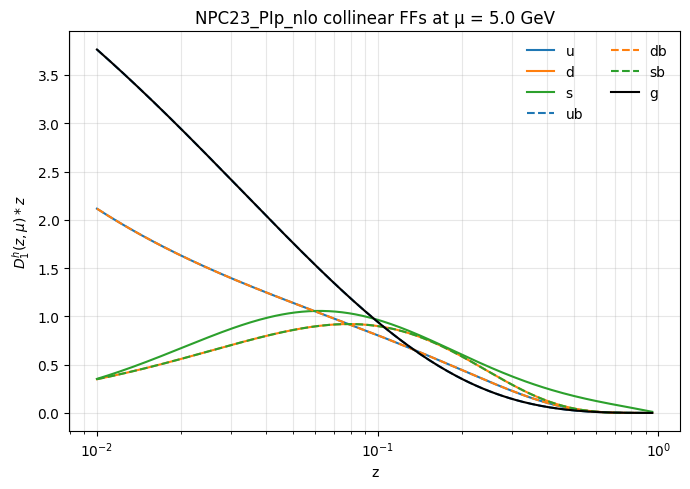

In [ ]:
z_grid = np.logspace(-2, np.log10(0.95), 250)
mu = 5.0

# PID map in your wrapper: [-5..5] => bb,cb,sb,db,ub,g,u,d,s,c,b
pid = {"u":1, "d":2, "s":3, "ub":-1, "db":-2, "sb":-3, "g":0}
colors = {"u":"C0","d":"C1","s":"C2","ub":"C0","db":"C1","sb":"C2","g":"k"}

def ff_array(pid_idx):
    return np.array([float(Main.get_pdfs(1, float(z), float(mu))[pid_idx]) for z in z_grid])

plt.figure(figsize=(7,5))
for flv in ["u","d","s","ub","db","sb","g"]:
    y = ff_array(pid[flv])
    ls = "--" if "b" in flv and flv != "g" else "-"
    plt.plot(z_grid, y*z_grid, ls=ls, c=colors[flv], label=flv)

plt.xscale("log")
plt.xlabel("z")
plt.ylabel(r"$D_1^h(z,\mu)*z$")
plt.title(f"NPC23_PIp_nlo collinear FFs at μ = {mu} GeV")
plt.grid(alpha=0.3, which="both")
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

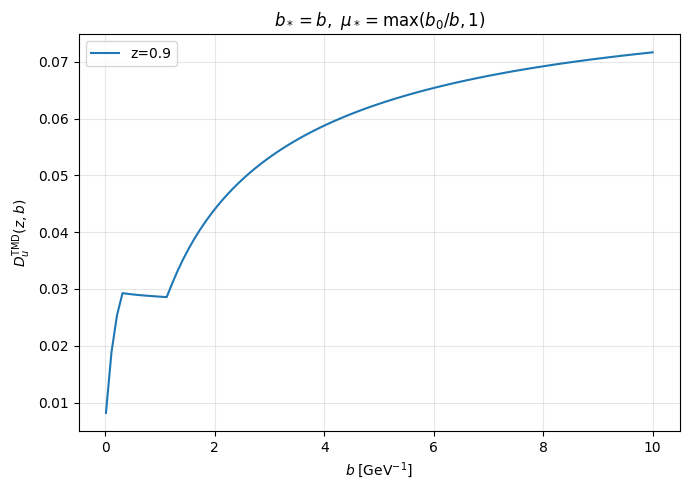

In [ ]:
z_list = [0.9]
b_grid = np.linspace(0.01, 10, 100)   # GeV^-1
Q = 10.0
b0 = float(Main.b0_default())

plt.figure(figsize=(7,5))

for z in z_list:
    vals = []
    for b in b_grid:
        bstar = b
        mustar = max(b0 / bstar, 1.0)
        a_s = float(Main.get_alphas(1, float(mustar))) / (4*np.pi)

        kwargs = {
            "z": float(z),
            "b": float(b),
            "μ": float(mustar),
            "Q": float(Q),
            "a_s": float(a_s),
            "use_dataset": True,
            "iset": 1,
        }
        vals.append(float(Main.TMDFF_u_NLO(**kwargs)))

    plt.plot(b_grid, np.array(vals)*z, label=f"z={z}")

plt.xlabel(r"$b\;[\mathrm{GeV}^{-1}]$")
plt.ylabel(r"$D_{u}^{\mathrm{TMD}}(z,b)$")
plt.title(r"$b_*=b,\ \mu_*=\max(b_0/b,1)$")
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()










